In [1]:
# =====================================================================
# CELL 1: SETUP & DATA PREPARATION (N=2, 1 CHANNEL)
# =====================================================================
!pip install sentencepiece transformers safetensors accelerate scikit-learn -q

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from collections import defaultdict

embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("SentenceTransformer loaded.")

from google.colab import drive
drive.mount('/content/drive')

# --- CONFIGURATION ---
NUM_SEEDS_TO_USE = 2
NUM_RUNS = 5

print(f"Loading Trajectories from Google Drive (Evaluating with {NUM_SEEDS_TO_USE} seeds)...")
dataset = np.load("/content/drive/MyDrive/llada/tvs_master_variance_arrays_extra.npz")
clean_traj = dataset['clean_traj']
conflict_traj = dataset['conflict_traj']

print("Loading Verified Master Dataset for base sentences...")
with open("/content/drive/MyDrive/llada/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

NUM_FACTS = clean_traj.shape[0]

# --- FAST BATCHED VARIANCE RECALCULATION ---
print(f"Recalculating Semantic Variance for {NUM_SEEDS_TO_USE} seeds...")
clean_raw_k, conflict_raw_k = [], []

for i in tqdm(range(NUM_FACTS), desc=f"Calculating Embeddings"):
    base_sentence = verified_eval_facts[i]["base"]

    c_traj_k = clean_traj[i, :NUM_SEEDS_TO_USE, :]
    conf_traj_k = conflict_traj[i, :NUM_SEEDS_TO_USE, :]
    K = c_traj_k.shape[0]

    c_flat = c_traj_k.T.flatten()
    conf_flat = conf_traj_k.T.flatten()
    all_texts = np.concatenate([c_flat, conf_flat])

    isolated_entities = []
    for text in all_texts:
        raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
        clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
        isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

    embeddings = embedder.encode(isolated_entities, batch_size=200, show_progress_bar=False)

    c_vars, conf_vars = [], []
    for step in range(50):
        start_idx = step * K
        step_embs = embeddings[start_idx : start_idx + K]
        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        c_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    offset = 50 * K
    for step in range(50):
        start_idx = offset + (step * K)
        step_embs = embeddings[start_idx : start_idx + K]
        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        conf_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    clean_raw_k.append(c_vars)
    conflict_raw_k.append(conf_vars)

clean_raw = np.array(clean_raw_k)
conflict_raw = np.array(conflict_raw_k)

# Delta TVS (Velocity) generation has been completely removed.
X_list, y_list = [], []
for i in range(NUM_FACTS):
    # Only append the raw variance (1 feature channel)
    X_list.append(np.expand_dims(clean_raw[i], axis=0))
    y_list.append(0)
    X_list.append(np.expand_dims(conflict_raw[i], axis=0))
    y_list.append(1)

# Format for PyTorch Models: [Batch, Time, Channels] -> [Batch, 50, 1]
X = torch.tensor(np.array(X_list), dtype=torch.float32).permute(0, 2, 1)
y = torch.tensor(y_list, dtype=torch.float32).unsqueeze(1)
indices = torch.arange(len(y)) # Used later to track dataset names across random splits
print(f"Data Prep Complete! X shape: {X.shape} (1 Channel)")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded.
Mounted at /content/drive
Loading Trajectories from Google Drive (Evaluating with 2 seeds)...
Loading Verified Master Dataset for base sentences...
Recalculating Semantic Variance for 2 seeds...


Calculating Embeddings: 100%|██████████| 2947/2947 [04:52<00:00, 10.08it/s]

Data Prep Complete! X shape: torch.Size([5894, 50, 1]) (1 Channel)


In [2]:
# =====================================================================
# CELL 2: MODEL ARCHITECTURES (UPDATED FOR 1 CHANNEL)
# =====================================================================
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        # Flatten the 50 timesteps * 1 feature channel (50 total features)
        self.fc = nn.Linear(50 * 1, 1)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

class UnidirectionalLSTM(nn.Module):
    def __init__(self):
        super(UnidirectionalLSTM, self).__init__()
        self.hidden_size = 32
        # Updated input_size=1
        self.lstm = nn.LSTM(input_size=1, hidden_size=self.hidden_size, num_layers=2, batch_first=True, dropout=0.3, bidirectional=False)
        self.attention = nn.Sequential(nn.Linear(self.hidden_size, self.hidden_size), nn.Tanh(), nn.Linear(self.hidden_size, 1))
        self.fc = nn.Sequential(nn.Linear(self.hidden_size, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(0.4), nn.Linear(16, 1), nn.Sigmoid())

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = F.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context_vector)

class BidirectionalLSTM(nn.Module):
    def __init__(self):
        super(BidirectionalLSTM, self).__init__()
        self.hidden_size = 32
        # Updated input_size=1
        self.lstm = nn.LSTM(input_size=1, hidden_size=self.hidden_size, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
        self.attention = nn.Sequential(nn.Linear(self.hidden_size * 2, self.hidden_size), nn.Tanh(), nn.Linear(self.hidden_size, 1))
        self.fc = nn.Sequential(nn.Linear(self.hidden_size * 2, 16), nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(0.4), nn.Linear(16, 1), nn.Sigmoid())

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = F.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context_vector)

MODELS = {
    "Logistic Regression": LogisticRegressionModel,
    "LSTM (Uni-directional)": UnidirectionalLSTM,
    "Bi-LSTM (Attention)": BidirectionalLSTM
}

In [3]:
# =====================================================================
# CELL 3: EVALUATION LOOP WITH DATASET BREAKDOWNS
# =====================================================================
BATCH_SIZE = 64
EPOCHS = 75
LEARNING_RATE = 0.002
WEIGHT_DECAY = 1e-4

results_summary = {}

for model_name, ModelClass in MODELS.items():
    print(f"\n{'='*70}")
    print(f"TRAINING {model_name.upper()} ACROSS {NUM_RUNS} RUNS")
    print(f"{'='*70}")

    acc_list, auroc_list = [], []

    # We will accumulate correctly predicted samples per dataset over all 5 test sets
    dataset_metrics = defaultdict(lambda: {"correct": 0, "total": 0})

    for run in range(NUM_RUNS):
        print(f"  -> Run {run+1}/{NUM_RUNS}", end="")

        # Split Data AND indices so we can identify what dataset each sample belongs to
        X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(X, y, indices, test_size=0.30, random_state=42+run, stratify=y)
        X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(X_temp, y_temp, idx_temp, test_size=0.50, random_state=42+run, stratify=y_temp)

        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

        model = ModelClass()
        criterion = nn.BCELoss()
        optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

        best_val_loss = float('inf')
        best_model_state = None

        for epoch in range(EPOCHS):
            model.train()
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(batch_X), batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            scheduler.step()

            model.eval()
            val_loss_accum = 0.0
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    val_loss_accum += criterion(model(batch_X), batch_y).item() * batch_X.size(0)
            avg_val_loss = val_loss_accum / len(X_val)

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model_state = model.state_dict().copy()

        # Evaluate on Test Set
        model.load_state_dict(best_model_state)
        model.eval()
        with torch.no_grad():
            test_probs = model(X_test)
            test_preds = (test_probs >= 0.5).float()

        acc = accuracy_score(y_test.numpy(), test_preds.numpy())
        auroc = roc_auc_score(y_test.numpy(), test_probs.numpy())

        acc_list.append(acc * 100)
        auroc_list.append(auroc)
        print(f" | Test Acc: {acc * 100:.2f}% | Test AUROC: {auroc:.4f}")

        # POPULATE DATASET METRICS (Only evaluated against unseen test data)
        test_preds_np = test_preds.numpy().squeeze()
        y_test_np = y_test.numpy().squeeze()
        idx_test_np = idx_test.numpy()

        for k in range(len(y_test_np)):
            true_label = int(y_test_np[k])
            pred_label = int(test_preds_np[k])

            # Divide by 2 because fact indices correspond to 2 tensor rows (clean=0, conflict=1)
            original_fact_index = idx_test_np[k] // 2
            fact = verified_eval_facts[original_fact_index]
            ds_name = fact.get("dataset", "unknown").upper()

            dataset_metrics[ds_name]["total"] += 1
            if true_label == pred_label:
                dataset_metrics[ds_name]["correct"] += 1

    # Average the per-dataset accuracy over the 5 runs
    ds_accuracy = {}
    for ds_name, counts in dataset_metrics.items():
        ds_accuracy[ds_name] = (counts["correct"] / counts["total"]) * 100

    results_summary[model_name] = {
        "mean_acc": np.mean(acc_list), "std_acc": np.std(acc_list),
        "mean_auroc": np.mean(auroc_list), "std_auroc": np.std(auroc_list),
        "dataset_accuracy": ds_accuracy
    }


TRAINING LOGISTIC REGRESSION ACROSS 5 RUNS
  -> Run 1/5 | Test Acc: 70.06% | Test AUROC: 0.7542
  -> Run 2/5 | Test Acc: 71.86% | Test AUROC: 0.7843
  -> Run 3/5 | Test Acc: 71.19% | Test AUROC: 0.7677
  -> Run 4/5 | Test Acc: 70.62% | Test AUROC: 0.7722
  -> Run 5/5 | Test Acc: 71.75% | Test AUROC: 0.7734

TRAINING LSTM (UNI-DIRECTIONAL) ACROSS 5 RUNS
  -> Run 1/5 | Test Acc: 71.86% | Test AUROC: 0.7831
  -> Run 2/5 | Test Acc: 71.41% | Test AUROC: 0.8027
  -> Run 3/5 | Test Acc: 71.86% | Test AUROC: 0.7794
  -> Run 4/5 | Test Acc: 72.88% | Test AUROC: 0.8018
  -> Run 5/5 | Test Acc: 70.17% | Test AUROC: 0.7833

TRAINING BI-LSTM (ATTENTION) ACROSS 5 RUNS
  -> Run 1/5 | Test Acc: 71.07% | Test AUROC: 0.7847
  -> Run 2/5 | Test Acc: 71.64% | Test AUROC: 0.7984
  -> Run 3/5 | Test Acc: 70.40% | Test AUROC: 0.7806
  -> Run 4/5 | Test Acc: 73.45% | Test AUROC: 0.8021
  -> Run 5/5 | Test Acc: 70.85% | Test AUROC: 0.7822



FINAL RESULTS: ARCHITECTURE COMPARISON
Logistic Regression:
  Overall Accuracy : 71.10% ± 0.68%
  Overall AUROC    : 0.7704 ± 0.0098

LSTM (Uni-directional):
  Overall Accuracy : 71.64% ± 0.88%
  Overall AUROC    : 0.7901 ± 0.0101

Bi-LSTM (Attention):
  Overall Accuracy : 71.48% ± 1.06%
  Overall AUROC    : 0.7896 ± 0.0088


PER-DATASET ACCURACY BREAKDOWN (Averaged across test sets)
             Logistic Regression  LSTM (Uni-directional)  Bi-LSTM (Attention)
POPQA                      71.52                   71.75                71.97
SYNTHETIC                  79.55                   80.86                80.86
SCIQ                       75.26                   75.21                74.88
COUNTERFACT                60.85                   62.13                62.06


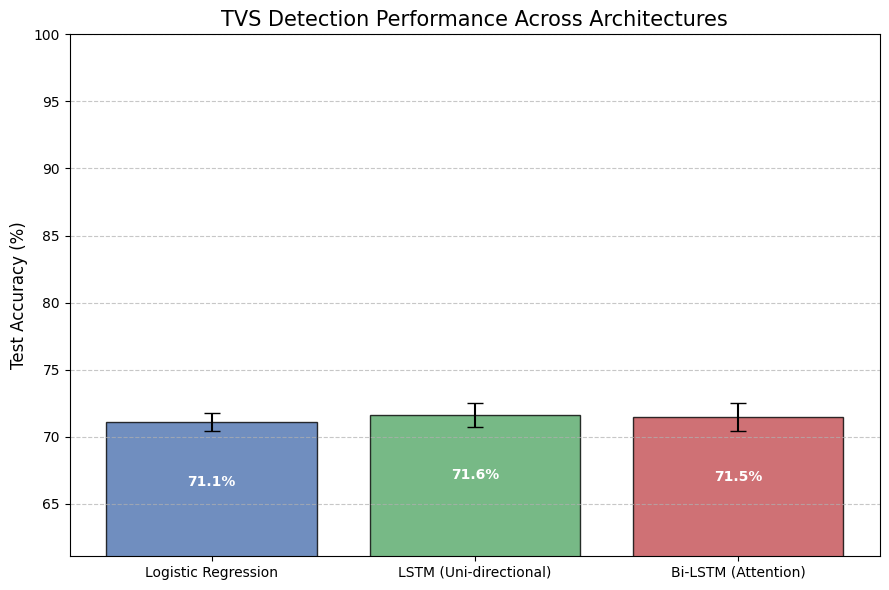

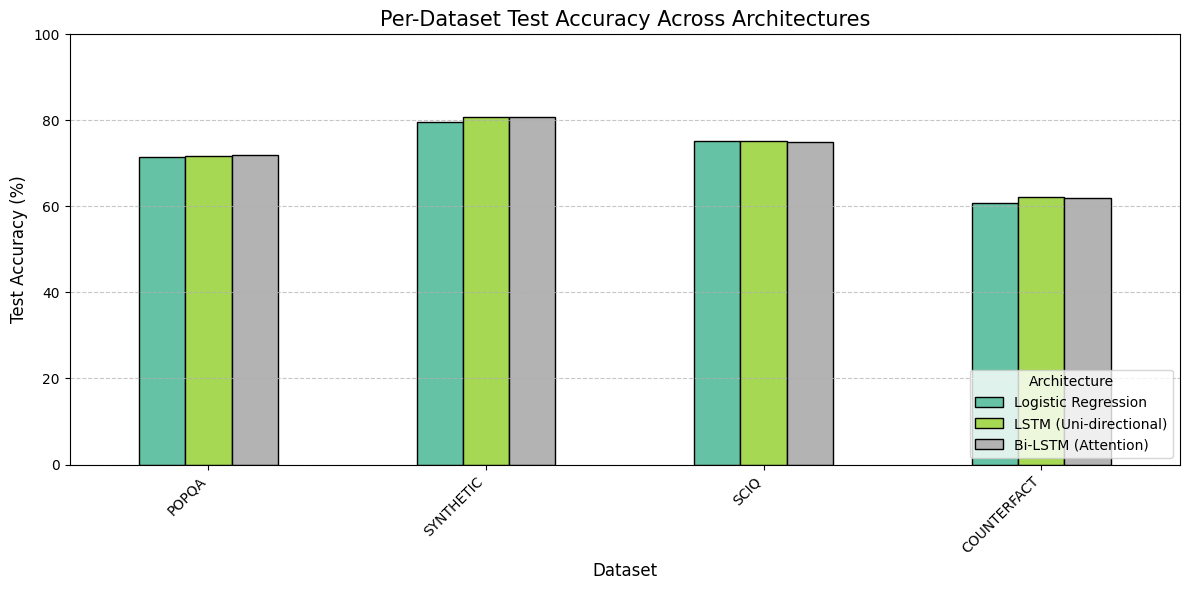

In [4]:
# =====================================================================
# CELL 4: VISUALIZATION & REPORTS
# =====================================================================
import pandas as pd

print("\n" + "="*50)
print("FINAL RESULTS: ARCHITECTURE COMPARISON")
print("="*50)
for model_name, metrics in results_summary.items():
    print(f"{model_name}:")
    print(f"  Overall Accuracy : {metrics['mean_acc']:.2f}% ± {metrics['std_acc']:.2f}%")
    print(f"  Overall AUROC    : {metrics['mean_auroc']:.4f} ± {metrics['std_auroc']:.4f}\n")

print("\n" + "="*50)
print("PER-DATASET ACCURACY BREAKDOWN (Averaged across test sets)")
print("="*50)

# Build a dataframe for clean tabular display and plotting
df_datasets = pd.DataFrame({model: data["dataset_accuracy"] for model, data in results_summary.items()})
print(df_datasets.round(2).to_string())

# --- 1. Graph: Overall Accuracy with Error Bars ---
models = list(results_summary.keys())
mean_accs = [results_summary[m]['mean_acc'] for m in models]
std_accs = [results_summary[m]['std_acc'] for m in models]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, mean_accs, yerr=std_accs, capsize=6, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 5, f'{yval:.1f}%', ha='center', va='bottom', color='white', fontweight='bold')

plt.title("TVS Detection Performance Across Architectures", fontsize=15)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.ylim(min(mean_accs)-10, 100) # Zoom in to see the difference clearly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/llada/architecture_comparison_overall.png", dpi=300)
plt.show()

# --- 2. Graph: Grouped Bar Chart for Per-Dataset Breakdown ---
df_datasets.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black')
plt.title("Per-Dataset Test Accuracy Across Architectures", fontsize=15)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Architecture", loc='lower right')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/llada/architecture_comparison_datasets.png", dpi=300)
plt.show()

--- PCA & SILHOUETTE SCORE ---
Silhouette Score on raw 50-D feature space: 0.0613
(A score > 0 indicates separation, though high dimensions often suppress raw silhouette scores)


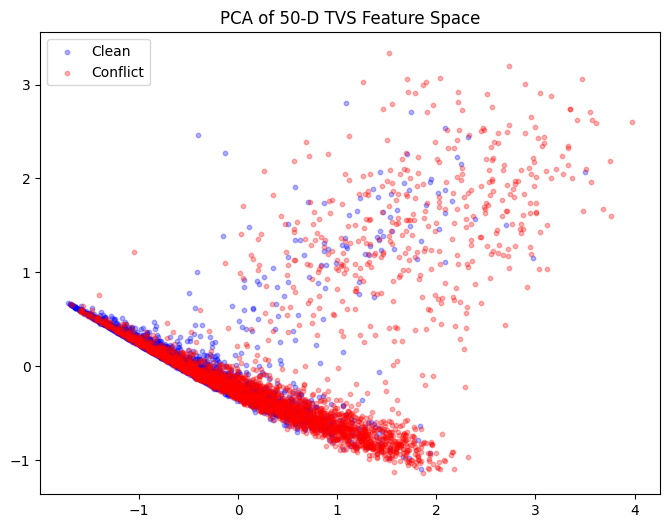

In [5]:
# =====================================================================
# PCA & SILHOUETTE SCORE (LINEAR SEPARABILITY CHECK)
# =====================================================================
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("--- PCA & SILHOUETTE SCORE ---")
# Flatten X from [Batch, 50, 1] to [Batch, 50]
X_np = X.numpy().squeeze()
y_np = y.numpy().squeeze()

sil_score = silhouette_score(X_np, y_np)
print(f"Silhouette Score on raw 50-D feature space: {sil_score:.4f}")
print("(A score > 0 indicates separation, though high dimensions often suppress raw silhouette scores)")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y_np == 0, 0], X_pca[y_np == 0, 1], alpha=0.3, label='Clean', color='blue', s=10)
plt.scatter(X_pca[y_np == 1, 0], X_pca[y_np == 1, 1], alpha=0.3, label='Conflict', color='red', s=10)
plt.title("PCA of 50-D TVS Feature Space")
plt.legend()
plt.show()

In [6]:
# =====================================================================
# TIMESTEP SHUFFLING TEST (LR vs LSTM)
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

print("--- TIMESTEP SHUFFLING TEST ---")

# Shuffle timesteps consistently across the dataset
np.random.seed(42)
shuffle_idx = np.random.permutation(50)
X_shuffled = X[:, shuffle_idx, :] # Keeps shape [Batch, 50, 1]

def evaluate_shuffled_model(ModelClass, X_data, name):
    acc_list = []
    # Running 3 random splits for a fast sanity check
    for run in range(3):
        X_train, X_temp, y_train, y_temp, _, _ = train_test_split(
            X_data, y, indices, test_size=0.30, random_state=42+run, stratify=y)
        X_val, X_test, y_val, y_test, _, _ = train_test_split(
            X_temp, y_temp, indices[len(X_train):], test_size=0.50, random_state=42+run, stratify=y_temp)

        train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)

        model = ModelClass()
        criterion = nn.BCELoss()
        optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)

        best_val = float('inf')
        best_state = None
        for epoch in range(40): # 40 epochs is plenty for this fast test
            model.train()
            for bx, by in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_loss = sum(criterion(model(bx), by).item() * bx.size(0) for bx, by in val_loader) / len(X_val)
            if val_loss < best_val:
                best_val = val_loss
                best_state = model.state_dict().copy()

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = (model(X_test) >= 0.5).float()
            acc_list.append(accuracy_score(y_test.numpy(), preds.numpy()) * 100)

    print(f"{name}: {np.mean(acc_list):.2f}% +/- {np.std(acc_list):.2f}%")

print("Evaluating Ordered Timesteps...")
evaluate_shuffled_model(LogisticRegressionModel, X, "LR (Ordered)")
evaluate_shuffled_model(UnidirectionalLSTM, X, "LSTM (Ordered)")

print("\nEvaluating Shuffled Timesteps...")
evaluate_shuffled_model(LogisticRegressionModel, X_shuffled, "LR (Shuffled)")
evaluate_shuffled_model(UnidirectionalLSTM, X_shuffled, "LSTM (Shuffled)")

--- TIMESTEP SHUFFLING TEST ---
Evaluating Ordered Timesteps...
LR (Ordered): 71.07% +/- 0.88%
LSTM (Ordered): 70.77% +/- 0.52%

Evaluating Shuffled Timesteps...
LR (Shuffled): 70.85% +/- 0.85%
LSTM (Shuffled): 70.62% +/- 0.96%
